# K-Means Clustering - Segmentasi Pelanggan Mall

**Nama:** Raihan Alfarizi

**Nim:** 1237050001

**Dataset:** Mall Customers (Annual Income & Spending Score)

**Tujuan:** Mengelompokkan pelanggan berdasarkan Annual Income dan Spending Score menggunakan K-Means Clustering.

## 1. Import Library

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

## 2. Load Dataset

In [ ]:
baca = pd.read_csv("data/mall_customers.csv")
baca.head()

,CustomerID,Gender,Age,Annual_Income_k,Spending_Score
0,1,Male,41,36,35
1,2,Female,69,39,33
2,3,Female,28,28,33
3,4,Female,66,19,37
4,5,Male,25,29,12


In [ ]:
baca.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   CustomerID       200 non-null    int64
 1   Gender           200 non-null    str  
 2   Age              200 non-null    int64
 3   Annual_Income_k  200 non-null    int64
 4   Spending_Score   200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [ ]:
baca.describe()

,CustomerID,Age,Annual_Income_k,Spending_Score
count,200.000000,200.000000,200.00000,200.000000
mean,100.500000,45.450000,64.49000,50.955000
std,57.879185,14.616625,36.11887,27.902432
min,1.000000,18.000000,15.00000,1.000000
25%,50.750000,34.750000,31.00000,29.750000
50%,100.500000,46.000000,63.00000,51.000000
75%,150.250000,57.000000,92.50000,76.000000
max,200.000000,69.000000,136.00000,99.000000


## 3. Preprocessing Data

In [ ]:
# Drop kolom yang tidak diperlukan
baca = baca.drop(["CustomerID", "Gender"], axis=1)
baca.head()

,Age,Annual_Income_k,Spending_Score
0,41,36,35
1,69,39,33
2,28,28,33
3,66,19,37
4,25,29,12


In [ ]:
# Menentukan variabel yang akan diklusterkan
baca_x = baca[["Annual_Income_k", "Spending_Score"]]
baca_x.head()

,Annual_Income_k,Spending_Score
0,36,35
1,39,33
2,28,33
3,19,37
4,29,12


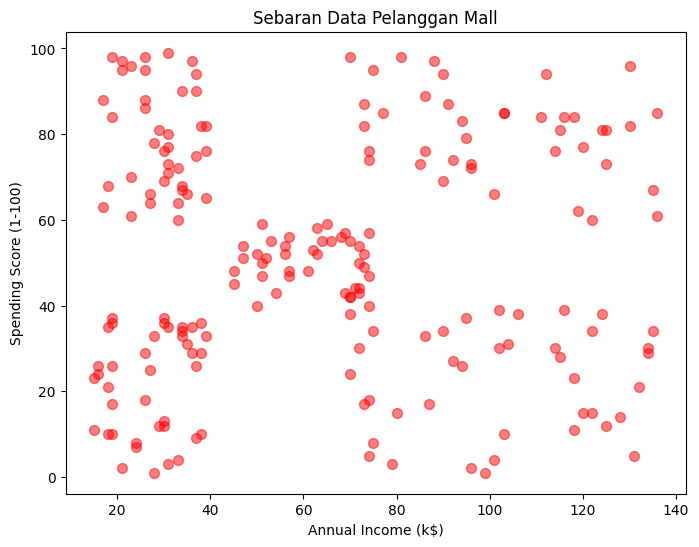

In [ ]:
# Memvisualisasikan persebaran data
plt.figure(figsize=(8, 6))
plt.scatter(baca["Annual_Income_k"], baca["Spending_Score"],
            s=50, c="red", marker="o", alpha=0.5)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Sebaran Data Pelanggan Mall")
plt.show()

## 4. Normalisasi Data (Min-Max Scaling)

In [ ]:
x_array = np.array(baca_x)
print(x_array[:5])

[[36 35]
 [39 33]
 [28 33]
 [19 37]
 [29 12]]


In [ ]:
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x_array)
print(x_scaled[:5])

[[0.17355372 0.34693878]
 [0.19834711 0.32653061]
 [0.10743802 0.32653061]
 [0.03305785 0.36734694]
 [0.11570248 0.1122449 ]]


## 5. Elbow Method - Menentukan K Optimal

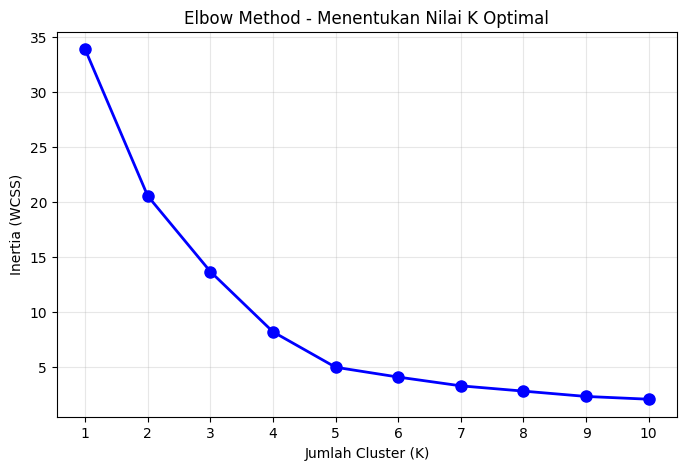

In [ ]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(x_scaled)
    inertia.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method - Menentukan Nilai K Optimal')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

## 6. Membuat Model K-Means (K=5)

In [ ]:
# Membuat model KMeans
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

# Training model
kmeans.fit(x_scaled)

# Menampilkan label cluster
print(kmeans.labels_)

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 1 4 4 1 4 1 4
 4 4 4 4 1 4 4 4 4 4 4 4 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]


In [ ]:
# Menambahkan hasil cluster ke dataframe
baca["kluster"] = kmeans.labels_
print(baca.head(10))

   Age  Annual_Income_k  Spending_Score  kluster
0   41               36              35        2
1   69               39              33        2
2   28               28              33        2
3   66               19              37        2
4   25               29              12        2
5   53               31               3        2
6   55               28               1        2
7   57               34              33        2
8   37               19              10        2
9   52               26              29        2


## 7. Visualisasi Hasil Clustering

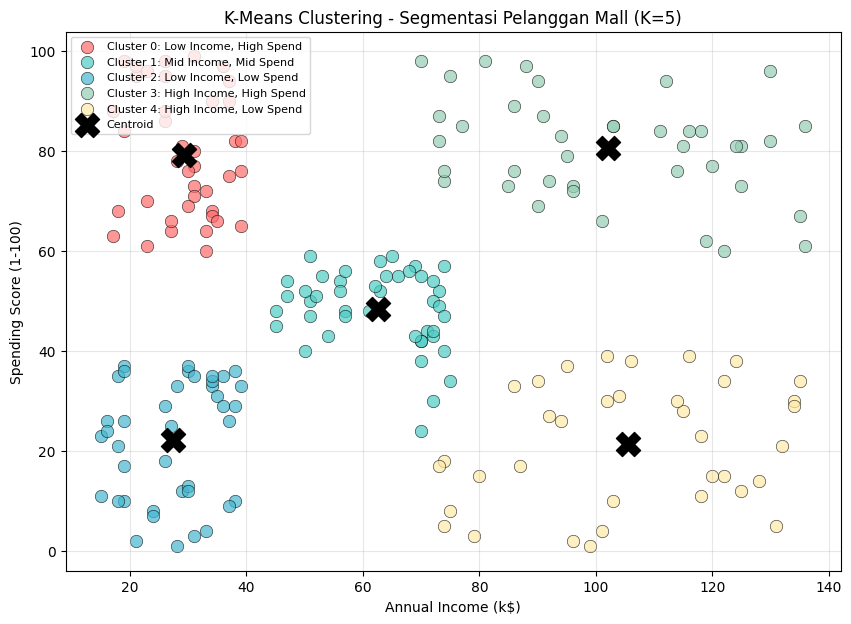

In [ ]:
colors = ["#FF6B6B", "#4ECDC4", "#45B7D1", "#96CEB4", "#FFEAA7"]
cluster_names = {
    0: "Low Income, High Spend",
    1: "Mid Income, Mid Spend",
    2: "Low Income, Low Spend",
    3: "High Income, High Spend",
    4: "High Income, Low Spend",
}

plt.figure(figsize=(10, 7))

for i in range(5):
    mask = baca["kluster"] == i
    plt.scatter(
        baca.loc[mask, "Annual_Income_k"],
        baca.loc[mask, "Spending_Score"],
        s=80, c=colors[i],
        label=f"Cluster {i}: {cluster_names[i]}",
        alpha=0.7, edgecolors="k", linewidths=0.5
    )

# Titik centroid
centers_orig = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centers_orig[:, 0], centers_orig[:, 1],
    s=300, c="black", marker="X", label="Centroid", zorder=5
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("K-Means Clustering - Segmentasi Pelanggan Mall (K=5)")
plt.legend(loc="upper left", fontsize=8)
plt.grid(True, alpha=0.3)
plt.show()

## 8. Analisis Hasil Cluster

In [ ]:
# Rata-rata fitur per cluster
cluster_analysis = baca.groupby("kluster")[["Age", "Annual_Income_k", "Spending_Score"]].mean().round(2)
cluster_analysis.index.name = "Cluster"
print(cluster_analysis)

           Age  Annual_Income_k  Spending_Score
Cluster                                        
0        49.70            29.22           79.22
1        45.02            62.57           48.48
2        44.08            27.38           22.28
3        43.78           102.02           80.62
4        44.64           105.56           21.47


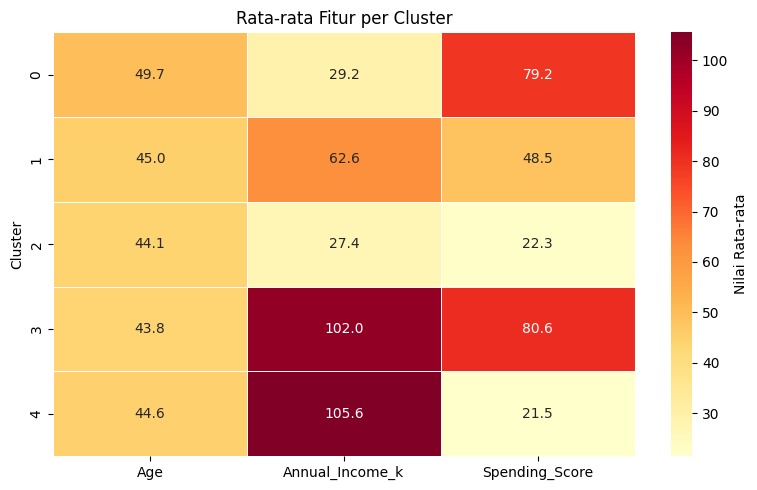

In [ ]:
# Heatmap analisis cluster
plt.figure(figsize=(8, 5))
sns.heatmap(cluster_analysis, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "Nilai Rata-rata"})
plt.title("Rata-rata Fitur per Cluster")
plt.tight_layout()
plt.show()

In [16]:
print(f"Inertia (WCSS) Final: {kmeans.inertia_:.4f}")
print("\nPosisi Centroid (Skala Asli):")
centroid_df = pd.DataFrame(centers_orig, columns=["Annual_Income_k", "Spending_Score"])
centroid_df.index.name = "Cluster"
print(centroid_df.round(2))

Inertia (WCSS) Final: 4.9885

Posisi Centroid (Skala Asli):
         Annual_Income_k  Spending_Score
Cluster                                 
0                  29.22           79.22
1                  62.57           48.48
2                  27.38           22.27
3                 102.02           80.63
4                 105.56           21.47
